# Importing used libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import datetime as dt

# Reading the file and displaying a sample 

In [3]:
pre = os.path.dirname(os.path.realpath("G:Retail_Data_Transactions.csv"))
fname ="Retail_Data_Transactions.csv"
patyh = os.path.join(pre,fname)

In [4]:
data = pd.read_csv("G:\\archive (1)\\Retail_Data_Transactions.csv")
df = pd.DataFrame(data)
print(df.head())
print(df.tail())

  customer_id trans_date  tran_amount
0      CS5295  11-Feb-13           35
1      CS4768  15-Mar-15           39
2      CS2122  26-Feb-13           52
3      CS1217  16-Nov-11           99
4      CS1850  20-Nov-13           78
       customer_id trans_date  tran_amount
124995      CS8433  26-Jun-11           64
124996      CS7232  19-Aug-14           38
124997      CS8731  28-Nov-14           42
124998      CS8133  14-Dec-13           13
124999      CS7996  13-Dec-14           36


 # we notice that there's no null values and the need of changing transaction     date from object to date


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  125000 non-null  object
 1   trans_date   125000 non-null  object
 2   tran_amount  125000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


# changing the date from object to datetime

In [6]:
df['trans_date'] = pd.to_datetime(df['trans_date'])
df['trans_date'] = df['trans_date'].dt.strftime('%Y-%m-%d')
df['trans_date'] = df['trans_date'].astype('datetime64[ns]')

In [7]:
print(df['trans_date'].min(), df['trans_date'].max())

2011-05-16 00:00:00 2015-03-16 00:00:00


In [8]:
timenow =dt.datetime(2015,3,17)
data["purchasedate"]= timenow -df['trans_date']
df['purchasedate'].astype('timedelta64[D]')
df['purchasedate']=df['purchasedate'] / np.timedelta64(1, 'D')
print(data.head())

  customer_id trans_date  tran_amount  purchasedate
0      CS5295 2013-02-11           35         764.0
1      CS4768 2015-03-15           39           2.0
2      CS2122 2013-02-26           52         749.0
3      CS1217 2011-11-16           99        1217.0
4      CS1850 2013-11-20           78         482.0


# here we start making the RFM 

In [9]:
rfm = df.groupby('customer_id').agg({'purchasedate': lambda x:x.min(),
                                    'customer_id': lambda x:len(x),
                                    'tran_amount': lambda x:x.sum()})

In [10]:
rfm.rename(columns={'purchasedate':'recency',
                    'customer_id':'frequency',
                    'tran_amount':'monetary'}, inplace = True)
rfm.head()

,recency,frequency,monetary
customer_id,,,
CS1112,62.0,15,1012
CS1113,36.0,20,1490
CS1114,33.0,19,1432
CS1115,12.0,22,1659
CS1116,204.0,13,857


In [11]:
rfm['recency'] = rfm['recency'].astype(int)

# making the quartiles using qcut

In [12]:
rfm['r_quartile'] = pd.qcut(rfm['recency'],4,['1','2','3','4'])
rfm['f_quartile'] = pd.qcut(rfm['frequency'],4,['4','3','2','1'])
rfm['m_quartile'] = pd.qcut(rfm['monetary'],4,['4','3','2','1'])
print(rfm.head())

             recency  frequency  monetary r_quartile f_quartile m_quartile
customer_id                                                               
CS1112            62         15      1012          3          3          3
CS1113            36         20      1490          2          2          2
CS1114            33         19      1432          2          2          2
CS1115            12         22      1659          1          2          1
CS1116           204         13       857          4          4          3


In [13]:
rfm['score'] = rfm.r_quartile.astype(str)+rfm.f_quartile.astype(str)+rfm.m_quartile.astype(str)
print(rfm.head())

             recency  frequency  monetary r_quartile f_quartile m_quartile  \
customer_id                                                                  
CS1112            62         15      1012          3          3          3   
CS1113            36         20      1490          2          2          2   
CS1114            33         19      1432          2          2          2   
CS1115            12         22      1659          1          2          1   
CS1116           204         13       857          4          4          3   

            score  
customer_id        
CS1112        333  
CS1113        222  
CS1114        222  
CS1115        121  
CS1116        443  


# now we view the most important and loyal customers with score 111 which indicates a frequant customer who purchased recently with a big amount of money 

In [14]:
print(rfm[rfm['score']=="111"].sort_values('monetary',ascending=False).head())

             recency  frequency  monetary r_quartile f_quartile m_quartile  \
customer_id                                                                  
CS4660            11         33      2527          1          1          1   
CS4608             1         32      2449          1          1          1   
CS5555            10         31      2439          1          1          1   
CS4540             1         32      2361          1          1          1   
CS4998            10         34      2358          1          1          1   

            score  
customer_id        
CS4660        111  
CS4608        111  
CS5555        111  
CS4540        111  
CS4998        111  


# plotting the data to have a good over view 

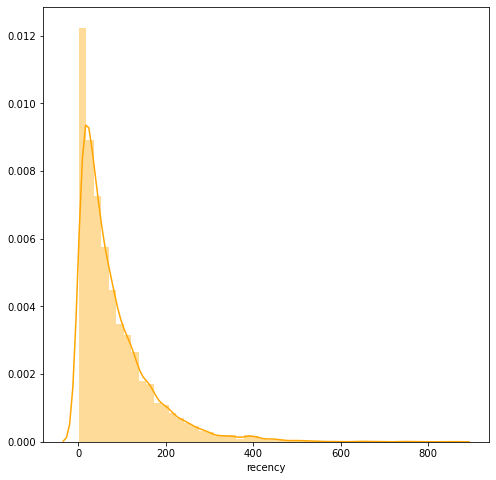

In [75]:
plt.figure(figsize=(8,8))
sns.set_palette(['orange'])
sns.distplot(rfm['recency'])

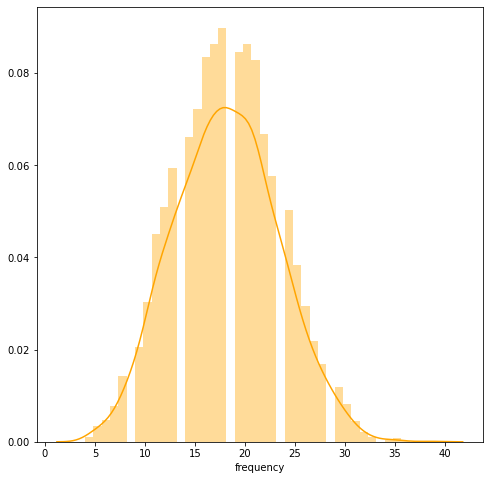

In [76]:
plt.figure(figsize=(8,8))
sns.set_palette(['orange'])
sns.distplot(rfm['frequency'])

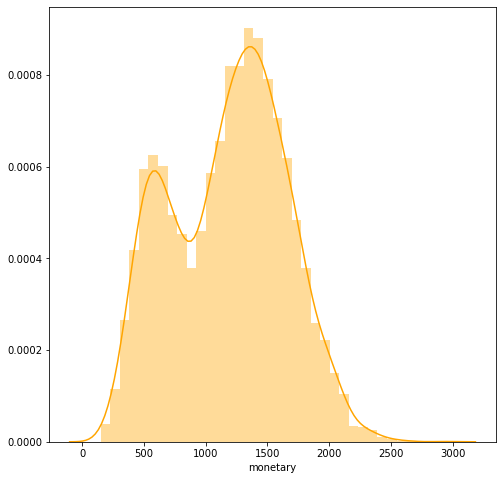

In [77]:
plt.figure(figsize=(8,8))
sns.set_palette(['orange'])
sns.distplot(rfm['monetary'])